In [1]:
import keras
from keras.datasets import cifar10
import matplotlib.pyplot as plt
%matplotlib inline

# Load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("Data shapes:")
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Data shapes:
x_train: (50000, 32, 32, 3)
x_test: (10000, 32, 32, 3)


Testing augmentation...


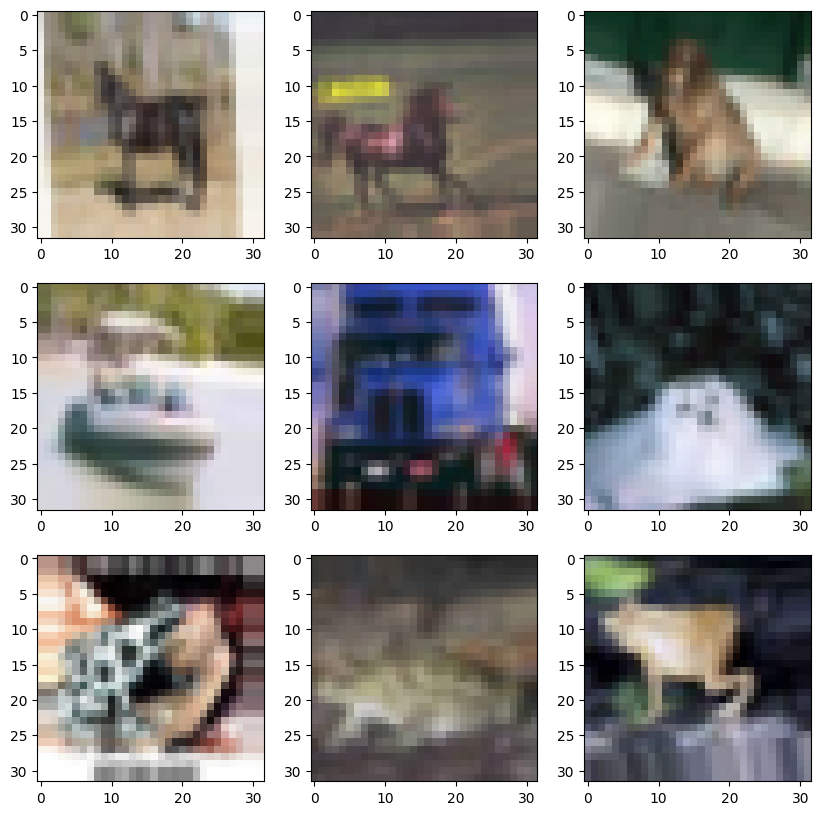

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

# Test augmentation
print("Testing augmentation...")
for X_batch, y_batch in datagen.flow(x_train, y_train, batch_size=9):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(X_batch[i])
    plt.show()
    break

In [4]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from keras.layers import BatchNormalization, Dropout

def create_model():
    model = Sequential([
        Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        MaxPooling2D(2,2),
        Dropout(0.2),

        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        MaxPooling2D(2,2),
        Dropout(0.3),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

model = create_model()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,746 (8.27 MB)

 Trainable params: 2,168,554 (8.27 MB)

 Non-trainable params: 192 (768.00 B)

In [5]:
from keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
batch_size = 64
epochs = 10  # Start with fewer epochs for testing

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=batch_size),
    steps_per_epoch=len(x_train)//batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


781/781 ━━━━━━━━━━━━━━━━━━━━ 394s 498ms/step - accuracy: 0.2667 - loss: 2.2359 - val_accuracy: 0.4596 - val_loss: 1.4595
Epoch 2/10
  1/781 ━━━━━━━━━━━━━━━━━━━━ 6:48 524ms/step - accuracy: 0.4219 - loss: 1.6810

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4219 - loss: 1.6810 - val_accuracy: 0.4529 - val_loss: 1.4655
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 421s 498ms/step - accuracy: 0.4328 - loss: 1.5498 - val_accuracy: 0.5398 - val_loss: 1.2749
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.5625 - loss: 1.3409 - val_accuracy: 0.5422 - val_loss: 1.2686
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 381s 488ms/step - accuracy: 0.5120 - loss: 1.3644 - val_accuracy: 0.5910 - val_loss: 1.2560
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.5469 - loss: 1.1551 - val_accuracy: 0.5866 - val_loss: 1.2656
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 382s 490ms/step - accuracy: 0.5596 - loss: 1.2361 - val_accuracy: 0.5751 - val_loss: 1.2604
Epoch 8/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7344 - loss: 1.0639 - val_accuracy: 0.6063 - val_loss: 1.1396
Epoch 9/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 415s 476ms/step - accuracy: 0.5997 - loss: 1.1424 - val

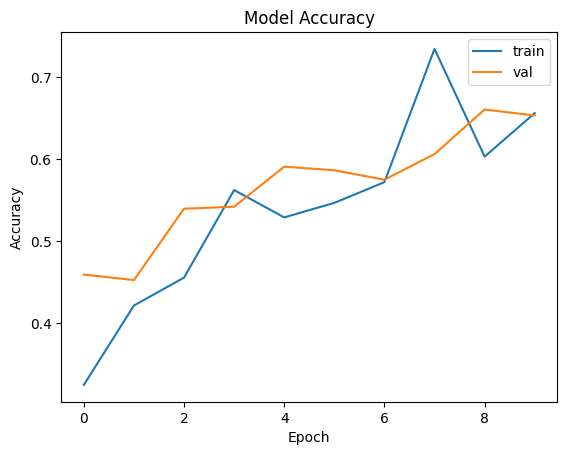

Test accuracy: 0.6533


In [7]:
# Plot training history
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Final evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")